In [19]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Analisando o Train_1 de 10...
Analisando o Train_2 de 10...
Analisando o Train_3 de 10...
Analisando o Train_4 de 10...
Analisando o Train_5 de 10...
Analisando o Train_6 de 10...
Analisando o Train_7 de 10...
Analisando o Train_8 de 10...
Analisando o Train_9 de 10...
Analisando o Train_10 de 10...


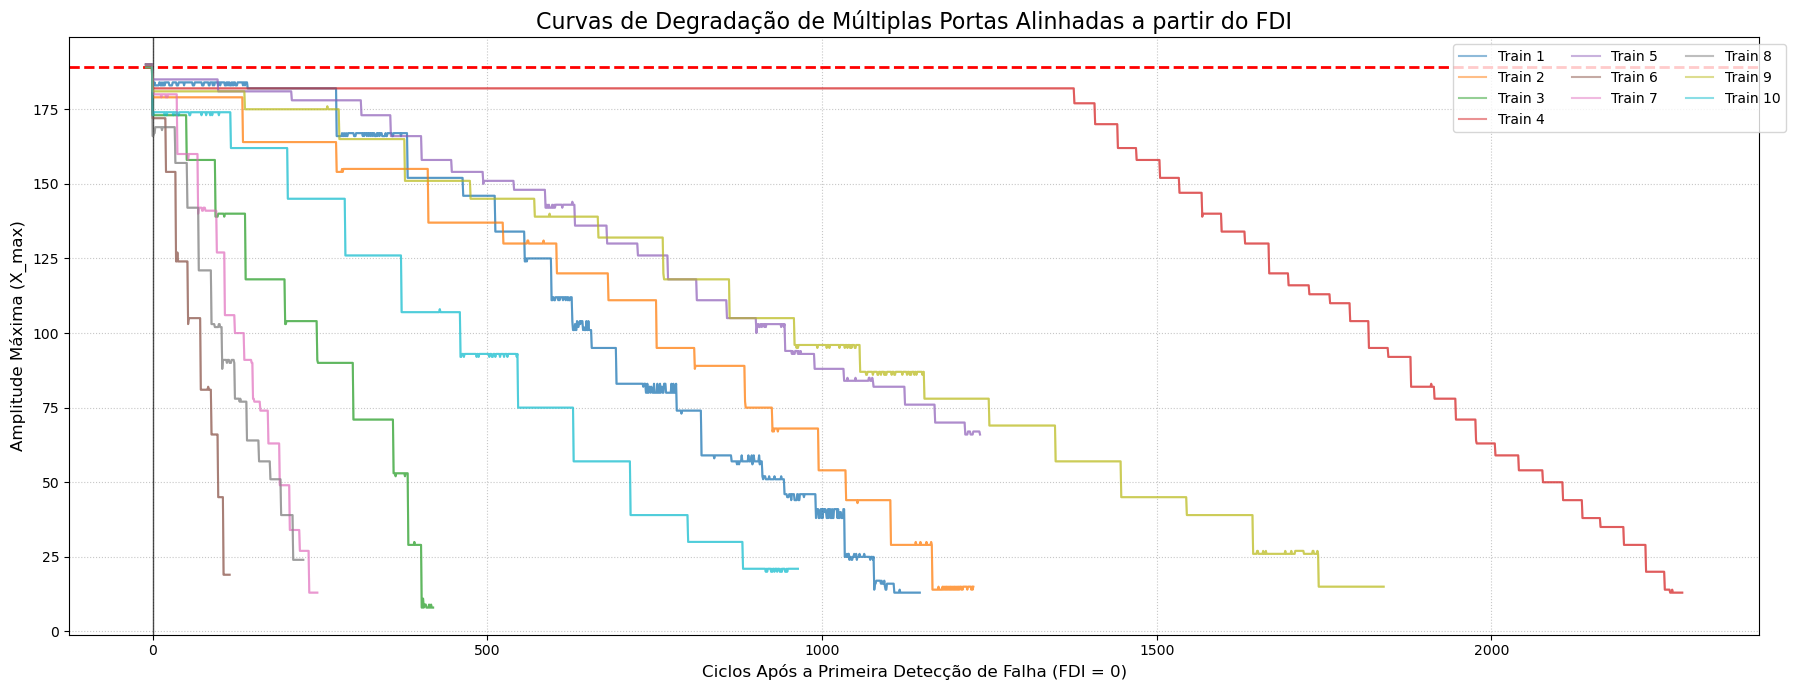

In [20]:
# Lista mestre para guardar os DataFrames de todas as portas já processadas
todas_as_portas = [] 

nomes_colunas = [
    "Duration", "Ref_Pos", "Fbk_Pos", "Ref_Vel", "Fbk_Vel", 
    "Fbk_Hall", "Fbk_Enc", "Vbus", "Temp_Motor", 
    "Corrente_A", "Corrente_B", "Corrente_C", 
    "Temp_Driver", "Volt_A", "Volt_B", "Volt_C"
]

# Loop para N portas
for i in range(1, 11):
    print(f"Analisando o Train_{i} de 10...")   # Coloquei 10 porque 48 demora bastante até plotar, mas pode ser qualquer quantidade

    caminho_pasta = f"Train/Train_{i}/"
    arquivo_rul = f"{caminho_pasta}F_{i}_RUL.csv"
    
    try:
        with open(arquivo_rul, 'r') as f:
            linha = f.readline()
            nCiclos = int(linha.strip())
    except FileNotFoundError:
        print(f"Erro: Arquivo RUL não encontrado na porta {i}")
        continue # Pula para a próxima porta se der erro

    dados_processados = []
    
    # Loop pelos ciclos da porta atual
    for j in range(1, nCiclos + 1):
        file_open = f"{caminho_pasta}F_{i}_{j:05d}_Opening.csv"
        
        if not os.path.exists(file_open):
            continue
            
        df_open = pd.read_csv(file_open, sep=';', header=None, names=nomes_colunas)
        
        x_max_atual = df_open['Fbk_Pos'].iloc[0] 
        
        dados_processados.append({
            'Ciclo': j,
            'X_max_Atual': x_max_atual
        })
    
    # Se não processou nenhum dado (arquivos faltando), pula
    if not dados_processados:
        continue
        
    # Transforma os dados da porta atual em DataFrame
    df_porta = pd.DataFrame(dados_processados)
    df_porta = df_porta.sort_values(by='Ciclo').reset_index(drop=True)
    
    # LÓGICA DO ALINHAMENTO DO PONTO DE DETECÇÃO (FDI = 0)
    fdi_row = df_porta[df_porta['X_max_Atual'] < 189.0]
    
    if not fdi_row.empty:
        # Descobre qual foi o ciclo real em que a porta começou a falhar
        fdi_ciclo = fdi_row['Ciclo'].iloc[0]
        
        # Cria uma nova coluna matemática: O FDI vira 0, o próximo vira 1, etc.
        df_porta['Ciclo_Relativo'] = df_porta['Ciclo'] - fdi_ciclo
        
        # Filtra para guardar na memória apenas do momento do FDI em diante
        df_porta_filtrada = df_porta[df_porta['Ciclo_Relativo'] >= -10]
        
        # Adiciona na nossa lista mestre (guardando o ID da porta e os dados)
        todas_as_portas.append((i, df_porta_filtrada))
    else:
        print(f"Aviso: Porta {i} nunca atingiu o FDI (<189) nos seus dados.")


# PLOTAGEM DO GRÁFICO COM AS 48 PORTAS

plt.figure(figsize=(18, 7))

# Percorre a lista mestre plotando uma linha de cada vez no mesmo gráfico
for porta_id, df_plot in todas_as_portas:
    # Eixo X é o Ciclo_Relativo (onde todas começam no 0)
    # Eixo Y é a Degradação (X_max_Atual)
    # Alpha = 0.5 deixa as linhas um pouco transparentes para não virar um borrão sólido
    plt.plot(df_plot['Ciclo_Relativo'], df_plot['X_max_Atual'], alpha=0.5, linewidth=1.5)

# Embelezando o gráfico
plt.title('Curvas de Degradação de Múltiplas Portas Alinhadas a partir do FDI', fontsize=16)
plt.xlabel('Ciclos Após a Primeira Detecção de Falha (FDI = 0)', fontsize=12)
plt.ylabel('Amplitude Máxima (X_max)', fontsize=12)

# Desenha uma linha vermelha tracejada marcando onde é o FDI (189.0)
plt.axhline(y=189.0, color='red', linestyle='--', linewidth=2)
plt.axvline(x=0, color='black', linestyle='-', linewidth=1.0, alpha=0.7)
for porta_id, df_plot in todas_as_portas:
    plt.plot(df_plot['Ciclo_Relativo'], df_plot['X_max_Atual'], 
             alpha=0.5, linewidth=1.5, label=f'Train {porta_id}')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper right', ncol=3, fontsize='medium')

plt.tight_layout()
plt.show()
